In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("C:/XMUM/2026.04/Advance Data Analytic/project_code/data/diabetic_flat_cleaned.csv")

df.head()

C:\Users\DELL\AppData\Local\Temp\ipykernel_2908\3882157823.py:9: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:/XMUM/2026.04/Advance Data Analytic/project_code/data/diabetic_flat_cleaned.csv")


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide_metformin,glipizide_metformin,glimepiride_pioglitazone,metformin_rosiglitazone,metformin_pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [2]:
df.shape

(101766, 50)

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

## Demographic Analysis

Age Distribution

In [4]:
df["age"].value_counts().sort_index()

age
[0-10)        161
[10-20)       691
[20-30)      1657
[30-40)      3775
[40-50)      9685
[50-60)     17256
[60-70)     22483
[70-80)     26068
[80-90)     17197
[90-100)     2793
Name: count, dtype: int64

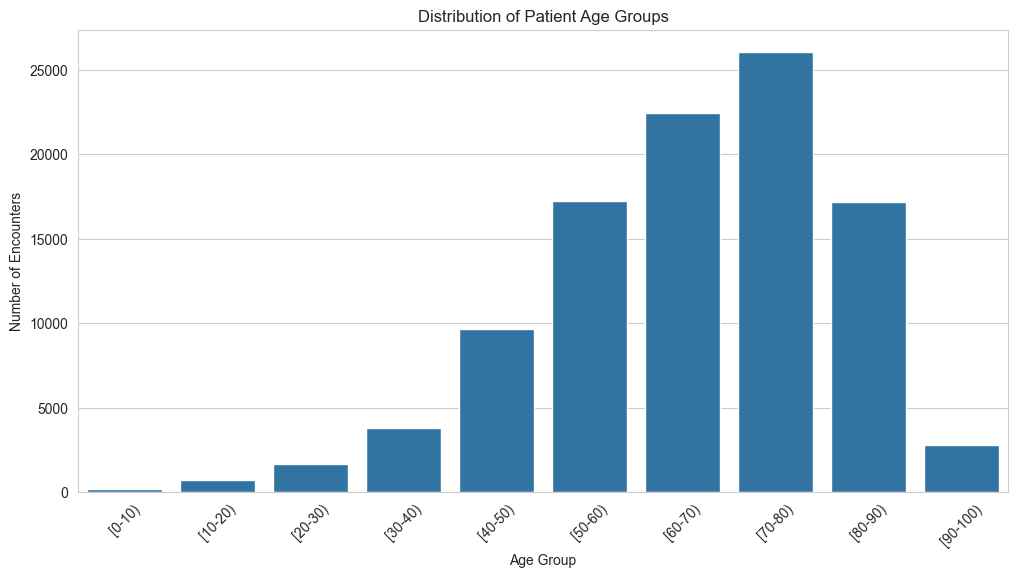

In [5]:
plt.figure(figsize=(12, 6))

age_order = sorted(
    df["age"].unique(),
    key=lambda x: int(x.strip("[]()").split("-")[0])
)

sns.countplot(
    data=df,
    x="age",
    order=age_order
)

plt.title("Distribution of Patient Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Number of Encounters")

plt.xticks(rotation=45)

plt.show()

Gender Distribution

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64


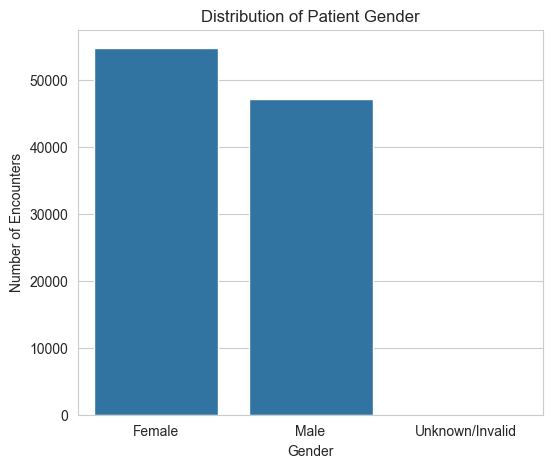

In [6]:
gender_counts = df["gender"].value_counts()

print(gender_counts)

plt.figure(figsize=(6, 5))

sns.countplot(
    data=df,
    x="gender",
    order=gender_counts.index
)

plt.title("Distribution of Patient Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Encounters")

plt.show()

Race Distribution

In [7]:
race_counts = (
    df["race"]
    .fillna("Unknown")
    .value_counts()
)

print(race_counts)

race
Caucasian          76099
AfricanAmerican    19210
Unknown             2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64


C:\Users\DELL\AppData\Local\Temp\ipykernel_2908\981064610.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


<Figure size 1000x600 with 0 Axes>

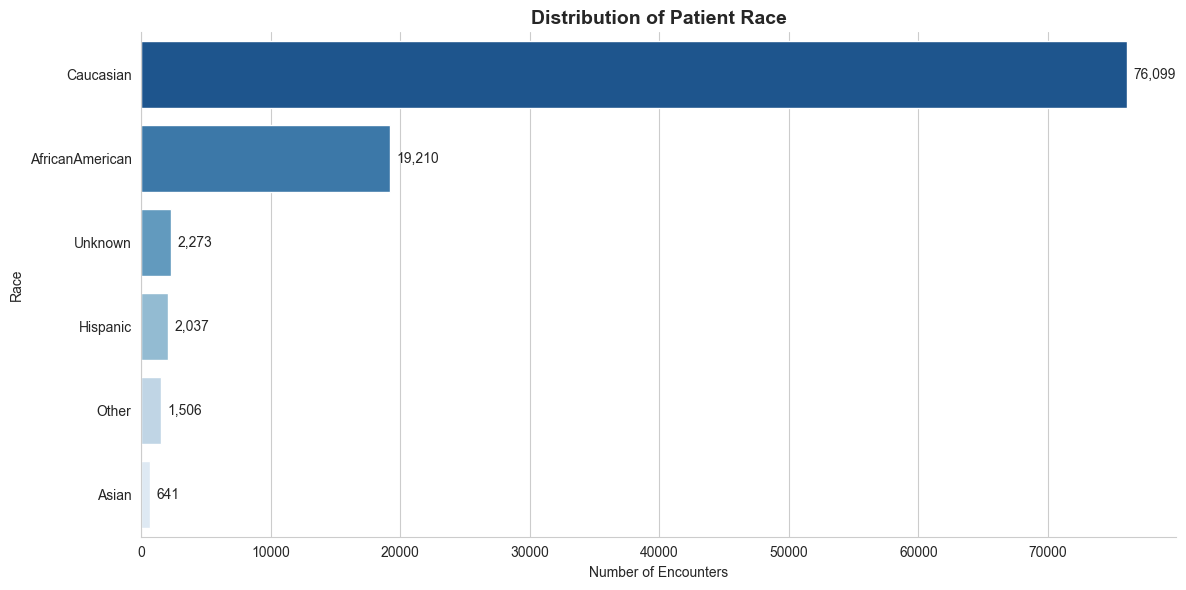

In [8]:
plt.figure(figsize=(10, 6))

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=race_counts.values,
    y=race_counts.index,
    palette="Blues_r"
)

plt.title(
    "Distribution of Patient Race",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Encounters")
plt.ylabel("Race")

for i, v in enumerate(race_counts.values):
    ax.text(
        v + 500,
        i,
        f"{v:,}",
        va="center"
    )

sns.despine()

plt.tight_layout()

plt.show()

## Clinical Analysis

Hospital Stay Duration

In [9]:
print(df["time_in_hospital"].describe())

count    101766.000000
mean          4.395987
std           2.985108
min           1.000000
25%           2.000000
50%           4.000000
75%           6.000000
max          14.000000
Name: time_in_hospital, dtype: float64


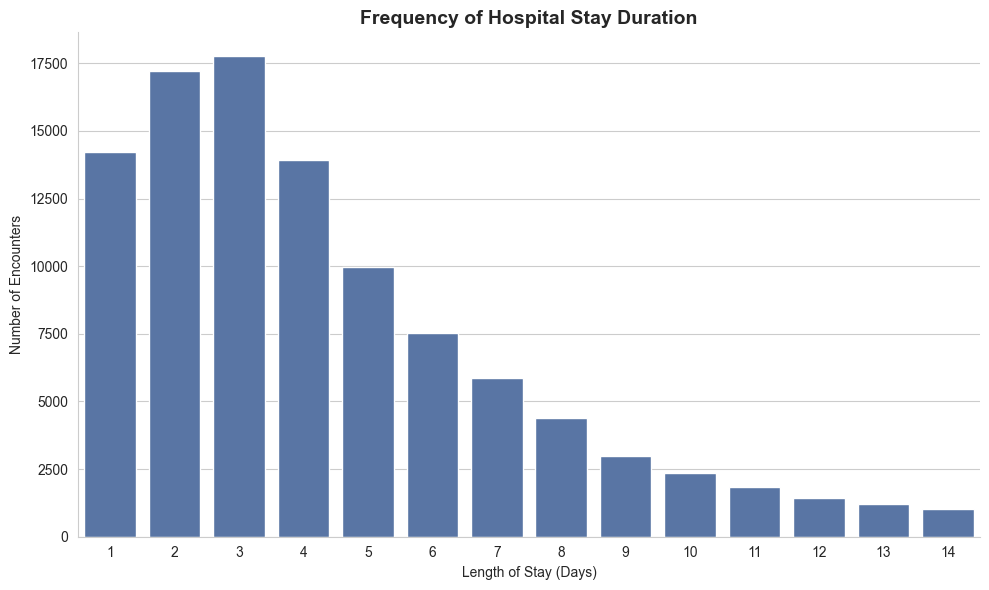

In [10]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="time_in_hospital",
    color="#4C72B0"
)

plt.title(
    "Frequency of Hospital Stay Duration",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Length of Stay (Days)")
plt.ylabel("Number of Encounters")

sns.despine()

plt.tight_layout()

plt.show()

Number of Medication

In [11]:
print(df["num_medications"].describe())

count    101766.000000
mean         16.021844
std           8.127566
min           1.000000
25%          10.000000
50%          15.000000
75%          20.000000
max          81.000000
Name: num_medications, dtype: float64


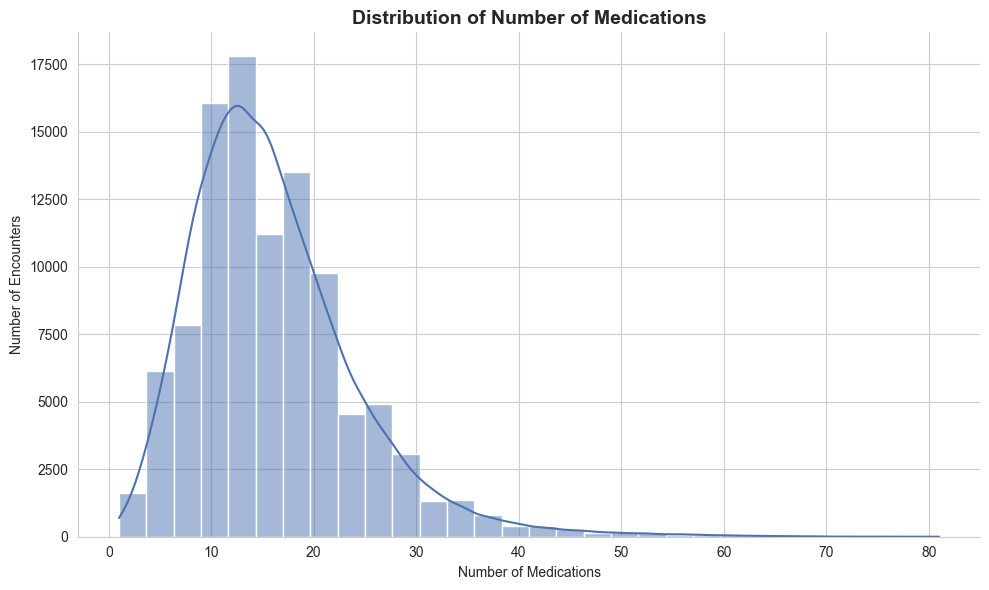

In [12]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["num_medications"],
    bins=30,
    kde=True,
    color="#4C72B0"
)

plt.title(
    "Distribution of Number of Medications",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Medications")
plt.ylabel("Number of Encounters")

sns.despine()

plt.tight_layout()

plt.show()

## Readmission Analysis

In [13]:
df["readmitted"].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [14]:
df["readmission_binary"] = (df["readmitted"] == "<30").astype(int)

Age vs Readmission Rate

In [15]:
readmission_age = pd.crosstab(
    df["age"],
    df["readmission_binary"],
    normalize="index"
) * 100

readmission_age = readmission_age.rename(
    columns={0: "No Readmission", 1: "Readmitted <30 Days"}
)

readmission_age

readmission_binary,No Readmission,Readmitted <30 Days
age,,
[0-10),98.136646,1.863354
[10-20),94.211288,5.788712
[20-30),85.757393,14.242607
[30-40),88.768212,11.231788
[40-50),89.395973,10.604027
[50-60),90.333797,9.666203
[60-70),88.871592,11.128408
[70-80),88.226945,11.773055
[80-90),87.916497,12.083503


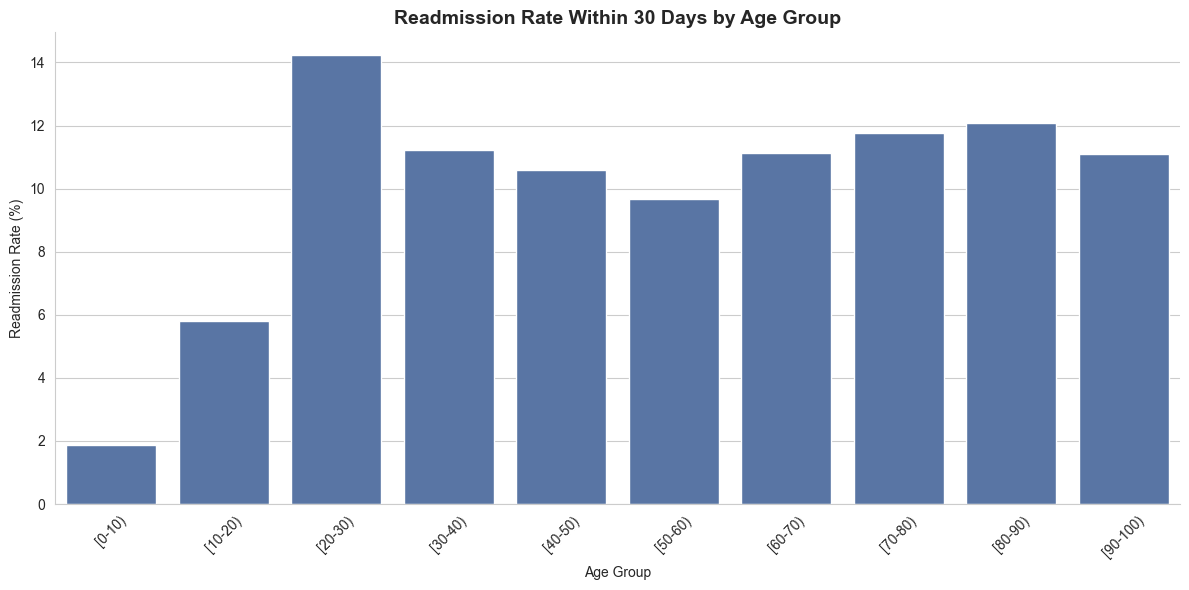

In [16]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=readmission_age.index,
    y=readmission_age["Readmitted <30 Days"],
    color="#4C72B0"
)

plt.title(
    "Readmission Rate Within 30 Days by Age Group",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Age Group")
plt.ylabel("Readmission Rate (%)")

plt.xticks(rotation=45)

sns.despine()

plt.tight_layout()

plt.show()

Hospital Stay Duration vs Readmission

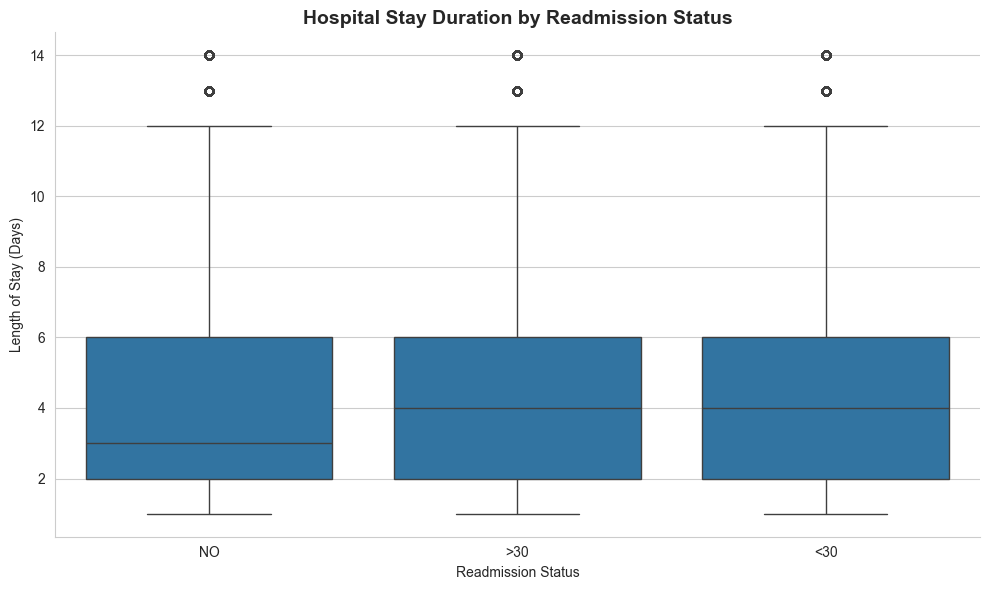

In [17]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="readmitted",
    y="time_in_hospital",
    order=["NO", ">30", "<30"]
)

plt.title(
    "Hospital Stay Duration by Readmission Status",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Readmission Status")
plt.ylabel("Length of Stay (Days)")

sns.despine()

plt.tight_layout()

plt.show()

In [18]:
df.groupby("readmitted")["time_in_hospital"].describe()

,count,mean,std,min,25%,50%,75%,max
readmitted,,,,,,,,
<30,11357.0,4.768249,3.028165,1.0,2.0,4.0,6.0,14.0
>30,35545.0,4.495541,2.988064,1.0,2.0,4.0,6.0,14.0
NO,54864.0,4.254429,2.964964,1.0,2.0,3.0,6.0,14.0


Number of Medication vs Readmission

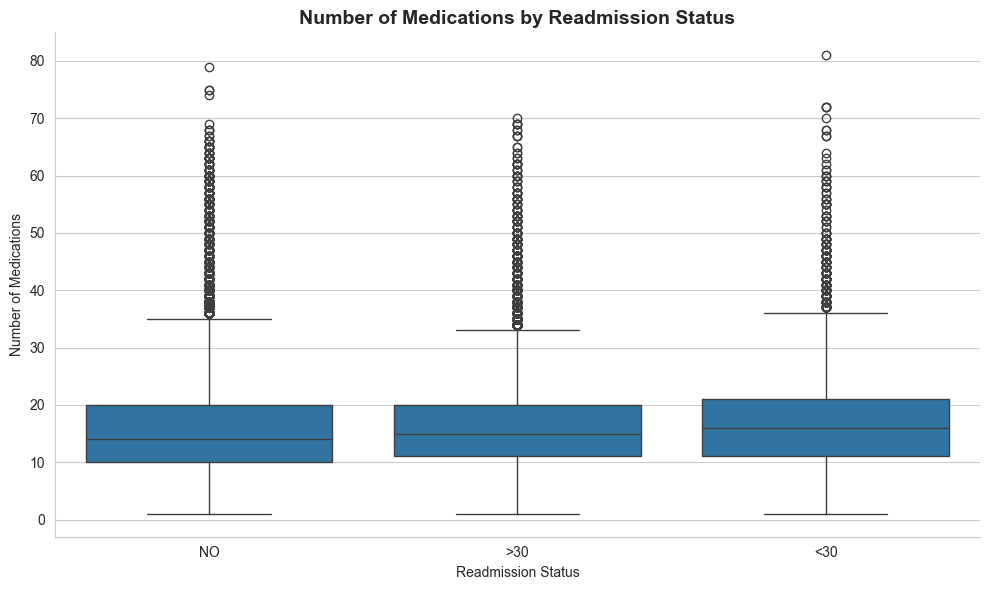

In [19]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="readmitted",
    y="num_medications",
    order=["NO", ">30", "<30"]
)

plt.title(
    "Number of Medications by Readmission Status",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Readmission Status")
plt.ylabel("Number of Medications")

sns.despine()

plt.tight_layout()

plt.show()

In [20]:
df.groupby("readmitted")["num_medications"].describe()

,count,mean,std,min,25%,50%,75%,max
readmitted,,,,,,,,
<30,11357.0,16.903143,8.096696,1.0,11.0,16.0,21.0,81.0
>30,35545.0,16.282768,7.618829,1.0,11.0,15.0,20.0,70.0
NO,54864.0,15.670367,8.427628,1.0,10.0,14.0,20.0,79.0


Correlation Heatmap

In [21]:
numeric_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

corr = df[numeric_cols].corr()

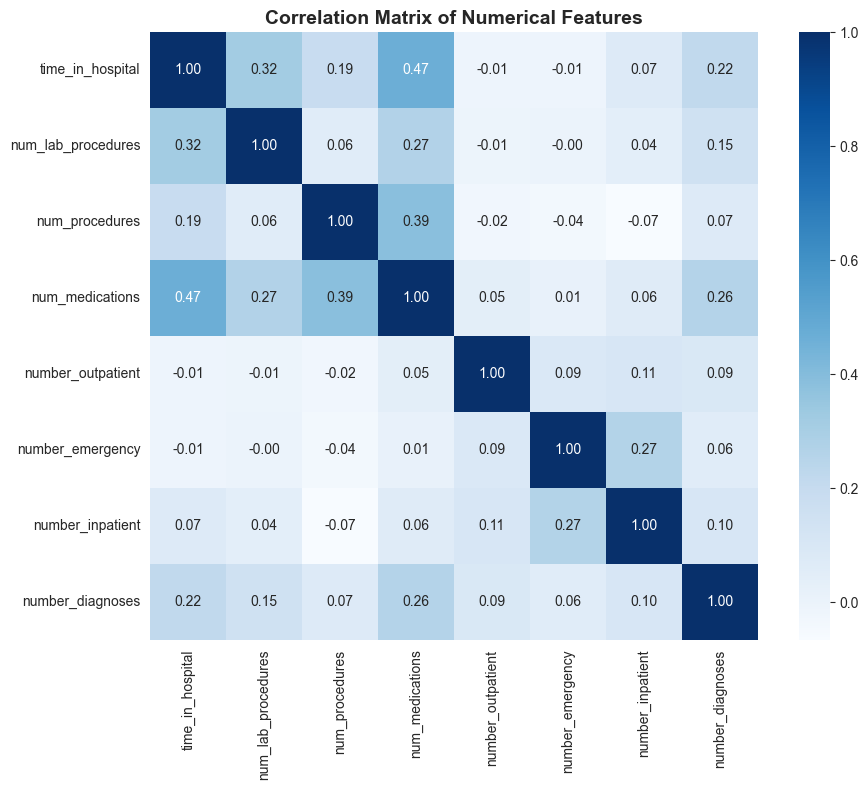

In [22]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    square=True
)

plt.title(
    "Correlation Matrix of Numerical Features",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

Patient Segmentation

In [23]:
segmentation_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X_seg = df[segmentation_features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_seg)

In [25]:
inertia = []

k_range = range(2, 11)

for k in k_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

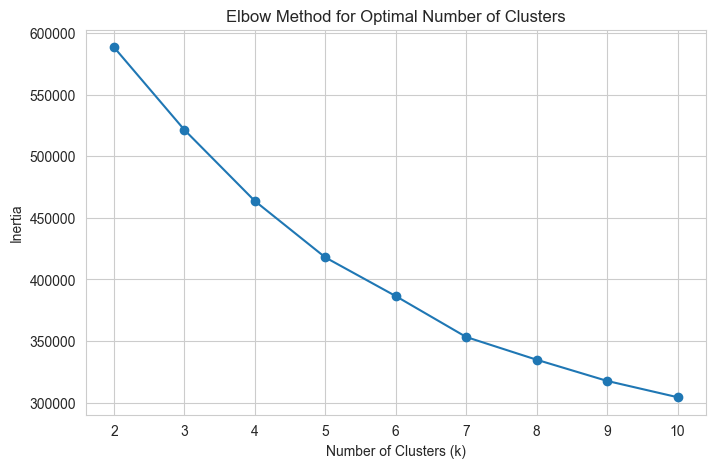

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_range,
    inertia,
    marker="o"
)

plt.title(
    "Elbow Method for Optimal Number of Clusters"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

plt.grid(True)

plt.show()

In [27]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X_scaled)

In [28]:
cluster_size = (df["cluster"].value_counts().sort_index())

print(cluster_size)

cluster
0    26880
1     4733
2    42610
3     3836
4    23707
Name: count, dtype: int64


In [29]:
cluster_profile = df.groupby("cluster")[segmentation_features].mean().round(2)

cluster_profile

,time_in_hospital,num_lab_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
cluster,,,,,,,
0,3.02,37.64,11.99,0.13,0.07,0.31,4.76
1,4.55,44.50,17.09,0.60,1.92,4.58,7.97
2,3.20,38.34,13.70,0.17,0.12,0.44,8.48
3,4.01,42.05,16.84,5.06,0.34,0.83,8.27
4,8.13,57.72,24.43,0.18,0.11,0.55,8.30


In [30]:
df["readmission_binary"] = (df["readmitted"] == "<30").astype(int)

cluster_readmission = (
    df.groupby("cluster")["readmission_binary"]
      .mean()
      .mul(100)
      .round(2)
)

cluster_readmission

cluster
0     8.20
1    28.12
2    10.40
3    12.07
4    12.36
Name: readmission_binary, dtype: float64

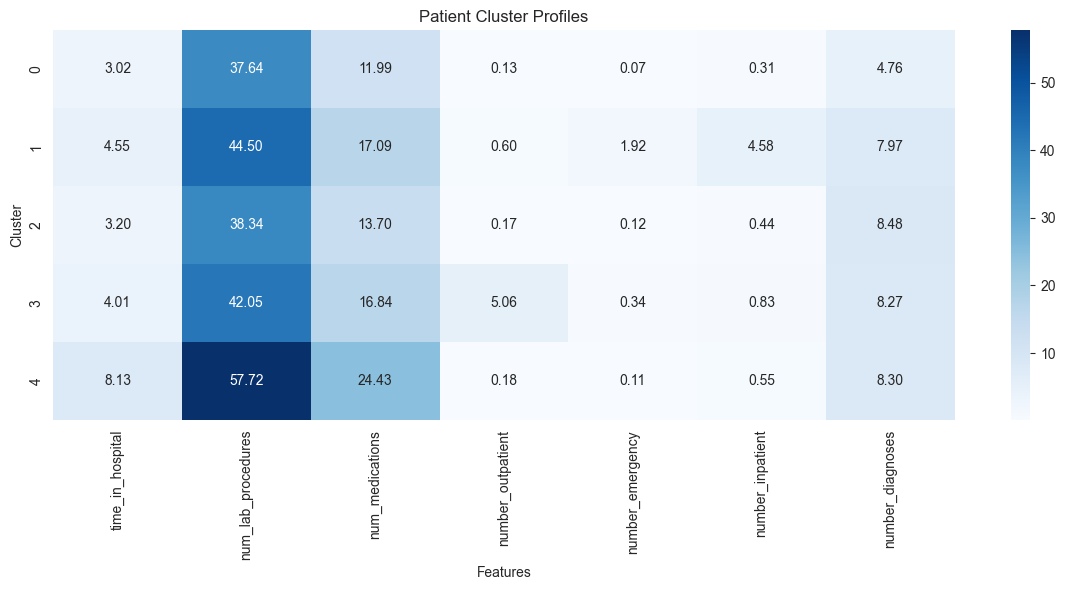

In [31]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title(
    "Patient Cluster Profiles"
)

plt.xlabel("Features")
plt.ylabel("Cluster")

plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_2908\1820180463.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


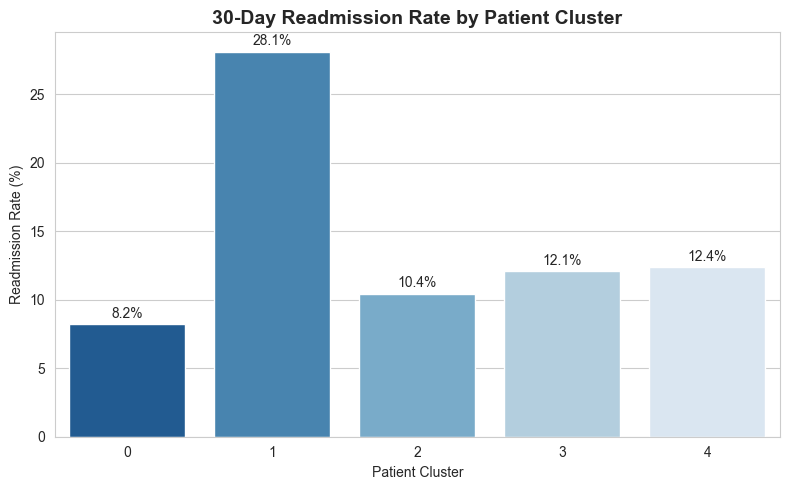

In [32]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=cluster_readmission.index,
    y=cluster_readmission.values,
    palette="Blues_r"
)

plt.title(
    "30-Day Readmission Rate by Patient Cluster",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Patient Cluster")
plt.ylabel("Readmission Rate (%)")

for i, v in enumerate(cluster_readmission.values):
    plt.text(
        i,
        v + 0.5,
        f"{v:.1f}%",
        ha="center"
    )

plt.tight_layout()

plt.show()